### README

In [4]:
# This script summarizes goal behaviors across players in quit condition 

### Import Packages

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

### Define File Paths

In [6]:
brick_wall_quit = "/Users/baselhussein/Projects/impossible_goals/brick_wall/data/conditions/brick_wall_quit.csv"

### Import Data 

In [7]:
df = pd.read_csv(brick_wall_quit)
df.head()

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses,time_offset
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,833
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,734


### Split Data 

In [8]:
df_explore = df[df['goals'].str.contains('goal_0')]
df_explore.head()

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses,time_offset
52,101,0:31:59:550,0:0:30:650,event,rule_remove,5:6:flag is win,1.643393e+12,"['baba is you ', 'wall is stop ']",NaN,goal_0,NaN,0
53,101,0:31:59:550,0:0:30:650,input,down,NaN,1.643393e+12,"['baba is you ', 'wall is stop ']",NaN,goal_0,NaN,0
54,101,0:32:5:500,0:0:36:600,change,update,baba:5:6:2,1.643393e+12,"['baba is you ', 'wall is stop ']",NaN,goal_0,NaN,5950
55,101,0:32:5:500,0:0:36:600,change,update,baba:4:6:2,1.643393e+12,"['baba is you ', 'wall is stop ']",NaN,goal_0,NaN,0
56,101,0:32:5:500,0:0:36:600,input,left,NaN,1.643393e+12,"['baba is you ', 'wall is stop ']",NaN,goal_0,NaN,0


In [9]:
df_goals = df[~df['goals'].str.contains('goal_0')]
df_goals.head()

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses,time_offset
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,833
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,734


### Descriptives

#### Count Number of Unique Goals By ID 

In [10]:
unique_goals_by_id = df_goals.groupby('ID')['goals'].nunique()
df_unique_goals_by_id = unique_goals_by_id.to_frame()
df_unique_goals_by_id.rename(columns={'goals': 'unique_goals'}, inplace=True)
df_unique_goals_by_id

,unique_goals
ID,
15,5
49,3
101,2
157,4
159,5
160,7
178,4
187,4
234,6


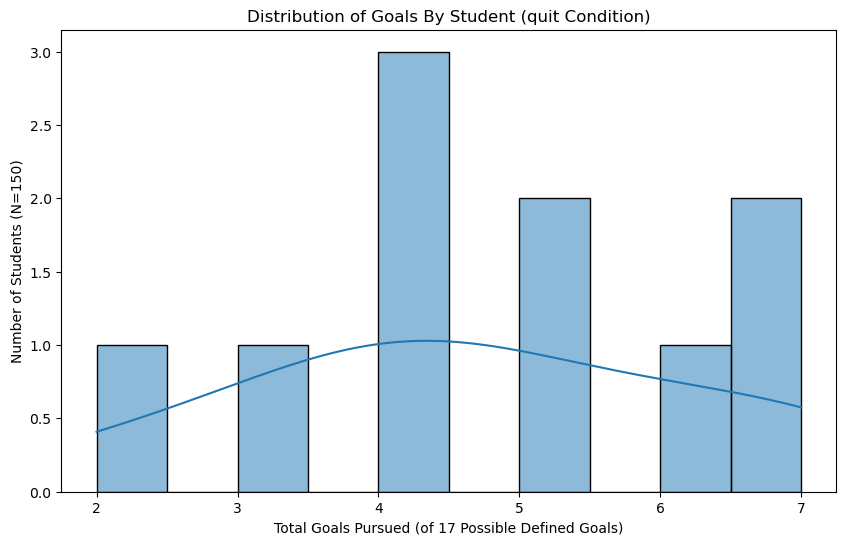

In [11]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_unique_goals_by_id['unique_goals'], bins=10, kde=True)
plt.title('Distribution of Goals By Student (quit Condition)')
plt.xlabel('Total Goals Pursued (of 17 Possible Defined Goals)')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/goals_by_student.png', dpi=300)
plt.show()

#### Number of Returns to Previous Goals

In [12]:
df_returns = df.copy()

In [13]:
for i in range(0, 18):
    df_returns['goals'] = df_returns['goals'].mask(
        df_returns['goals'].eq(f'goal_{i}') & df_returns['goals'].shift().eq(f'goal_{i}')
    )

In [14]:
df_returns

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses,time_offset
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN,0
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN,0
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN,833
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN,0
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN,734
...,...,...,...,...,...,...,...,...,...,...,...,...
16603,49,0:54:52:550,0:2:6:350,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN,0
16604,49,0:54:52:800,0:2:6:600,change,update,baba:2:6:2,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN,250
16605,49,0:54:52:800,0:2:6:600,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN,0
16606,49,0:55:12:433,0:2:26:233,input,end,NaN,1.643671e+12,NaN,quit,NaN,NaN,19633


In [15]:
df_switches_goal = df_returns.groupby('ID')['goals'].value_counts().unstack(fill_value = 'None')
df_switches_goal

goals,goal_0,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9
ID,,,,,,,,,,
15,20,10,8,None,3,1,1,None,None,None
49,6,3,None,2,1,None,None,None,None,None
101,2,1,None,None,None,None,None,None,None,1
157,11,7,None,None,1,1,None,None,2,None
159,34,24,None,None,4,3,None,None,2,1
160,31,11,6,1,4,5,None,2,2,None
178,7,4,None,None,1,1,None,None,None,1
187,19,11,None,None,2,6,3,None,None,None
234,21,8,4,2,4,2,None,None,None,1


In [16]:
print(df_switches_goal.columns)

Index(['goal_0', 'goal_1', 'goal_10', 'goal_12', 'goal_2', 'goal_3', 'goal_4',
       'goal_5', 'goal_7', 'goal_9'],
      dtype='object', name='goals')


In [17]:
df_switches_goal.drop(columns=['goal_0'], inplace=True)

In [18]:
df_returns_goal = df_switches_goal.applymap(lambda x: x - 1 if isinstance(x, (int, float)) else x)
df_returns_goal

goals,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9
ID,,,,,,,,,
15,9,7,None,2,0,0,None,None,None
49,2,None,1,0,None,None,None,None,None
101,0,None,None,None,None,None,None,None,0
157,6,None,None,0,0,None,None,1,None
159,23,None,None,3,2,None,None,1,0
160,10,5,0,3,4,None,1,1,None
178,3,None,None,0,0,None,None,None,0
187,10,None,None,1,5,2,None,None,None
234,7,3,1,3,1,None,None,None,0


In [19]:
df_returns_numeric = df_returns_goal.replace('None', 0)
df_returns_numeric['total'] = df_returns_numeric.sum(axis=1)
df_returns_numeric

goals,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
ID,,,,,,,,,,
15,9,7,0,2,0,0,0,0,0,18
49,2,0,1,0,0,0,0,0,0,3
101,0,0,0,0,0,0,0,0,0,0
157,6,0,0,0,0,0,0,1,0,7
159,23,0,0,3,2,0,0,1,0,29
160,10,5,0,3,4,0,1,1,0,24
178,3,0,0,0,0,0,0,0,0,3
187,10,0,0,1,5,2,0,0,0,18
234,7,3,1,3,1,0,0,0,0,15


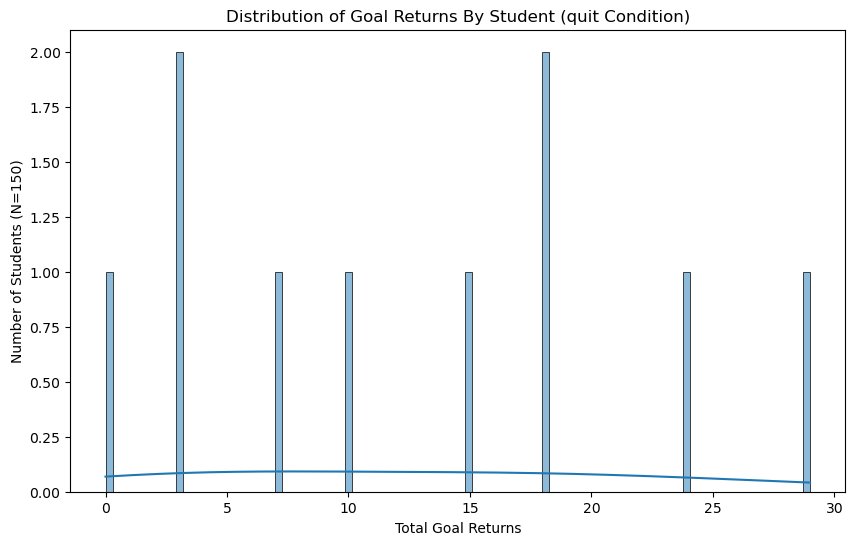

In [20]:
# Visualize the distribution of the 'Total' column

plt.figure(figsize=(10, 6))
sns.histplot(df_returns_numeric['total'], bins=100, kde=True)
plt.title('Distribution of Goal Returns By Student (quit Condition)')
plt.xlabel('Total Goal Returns')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/goal_returns_by_student.png', dpi=300)
plt.show()

#### Count Number of Goal Switches 

In [21]:
df_switches_numeric = df_switches_goal.replace('None', 0)
df_switches_numeric['total'] = df_switches_numeric.sum(axis=1)
df_switches_numeric

goals,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
ID,,,,,,,,,,
15,10,8,0,3,1,1,0,0,0,23
49,3,0,2,1,0,0,0,0,0,6
101,1,0,0,0,0,0,0,0,1,2
157,7,0,0,1,1,0,0,2,0,11
159,24,0,0,4,3,0,0,2,1,34
160,11,6,1,4,5,0,2,2,0,31
178,4,0,0,1,1,0,0,0,1,7
187,11,0,0,2,6,3,0,0,0,22
234,8,4,2,4,2,0,0,0,1,21


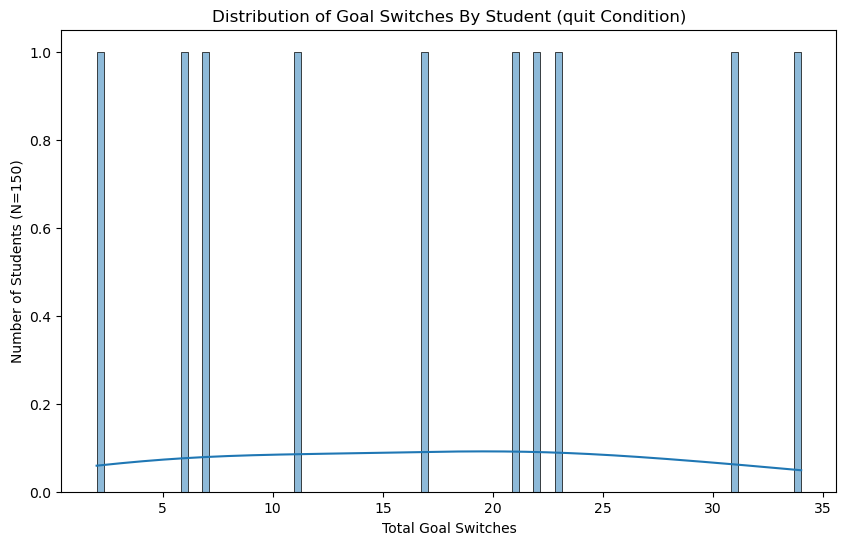

In [22]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_switches_numeric['total'], bins=100, kde=True)
plt.title('Distribution of Goal Switches By Student (quit Condition)')
plt.xlabel('Total Goal Switches')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/goal_switches_by_student.png', dpi=300)
plt.show()

#### Count Total Impasses

In [23]:
impasses_counts_by_player = df.groupby('ID')['impasses'].count()
df_impasses_counts_by_player = impasses_counts_by_player.to_frame()
df_impasses_counts_by_player

,impasses
ID,
15,72
49,19
69,0
101,8
157,23
159,121
160,63
178,24
187,131


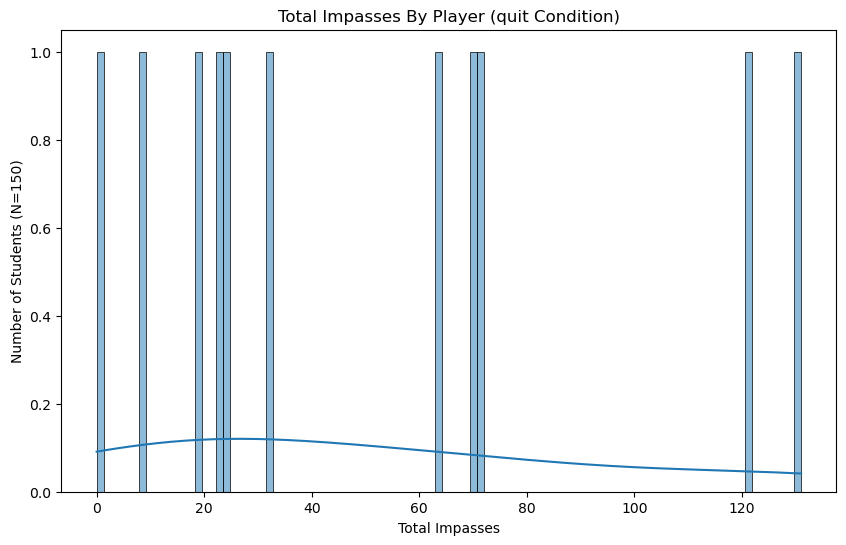

In [24]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_impasses_counts_by_player['impasses'], bins=100, kde=True)
plt.title('Total Impasses By Player (quit Condition)')
plt.xlabel('Total Impasses')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/total_impasses_by_player_in_level.png', dpi=300)
plt.show()

#### Count Impasses By Goal, By Player 

In [25]:
goal_impasse_counts = df_goals.groupby(['ID', 'goals']).agg({'impasses': 'count'}).reset_index()
goal_impasse_counts_pre_solution = goal_impasse_counts[~goal_impasse_counts['goals'].isin(['goal_16', 'goal_17'])]
goal_impasse_counts_pre_solution

,ID,goals,impasses
0,15,goal_1,14
1,15,goal_10,14
2,15,goal_2,7
3,15,goal_3,0
4,15,goal_4,29
5,49,goal_1,8
6,49,goal_12,6
7,49,goal_2,5
8,101,goal_1,6
9,101,goal_9,1


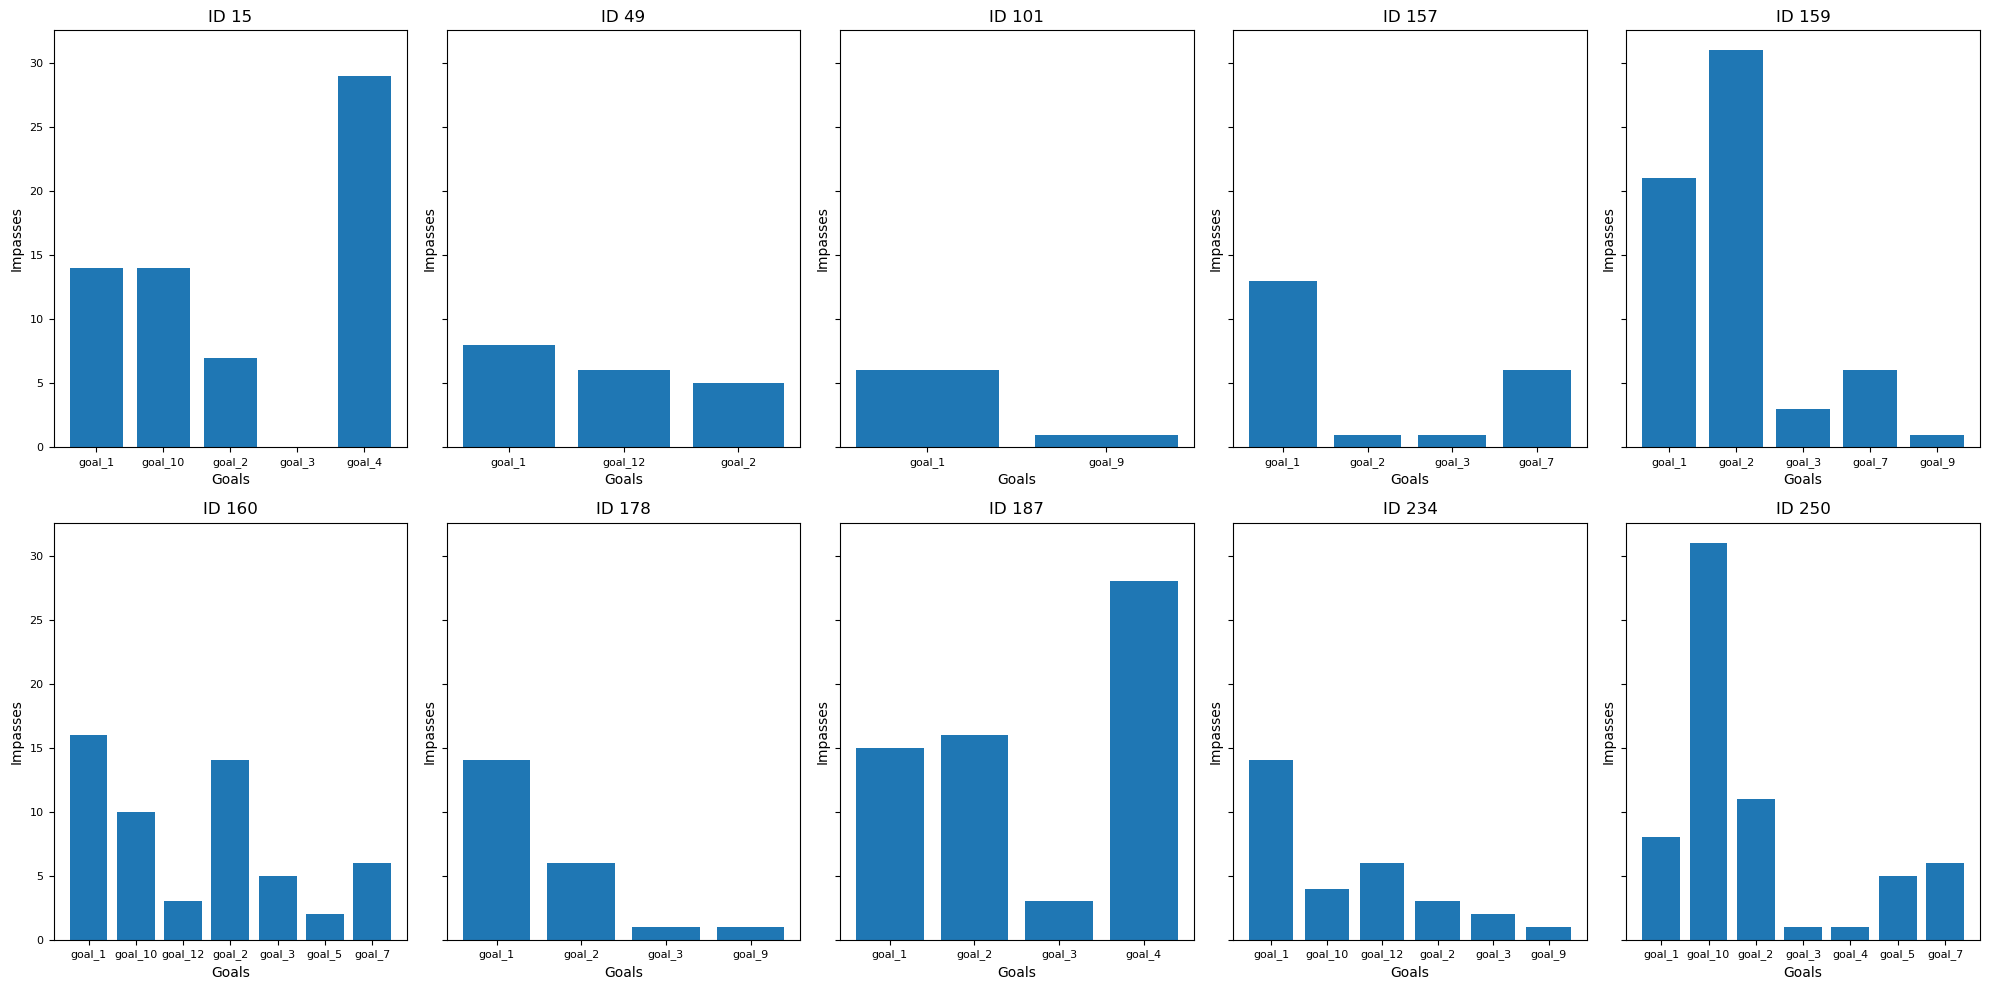

In [26]:
# Get unique IDs
unique_ids = goal_impasse_counts_pre_solution['ID'].unique()

# Set up the plot grid
num_cols = 5  # Number of columns
num_rows = int(np.ceil(len(unique_ids) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5*num_rows), sharey=True)

# Flatten the axes array if there's only one row
if num_rows == 1:
    axes = axes.reshape(1, -1)

# Plot each ID's data in a subplot
for i, uid in enumerate(unique_ids):
    ax = axes[i // num_cols, i % num_cols]  # Get the appropriate subplot
    id_data = goal_impasse_counts_pre_solution[goal_impasse_counts_pre_solution['ID'] == uid]  # Data for the current ID
    goals = id_data['goals']
    impasses = id_data['impasses']
    ax.bar(goals, impasses)
    ax.set_title(f'ID {uid}', fontsize=12)  # Set title font size
    ax.set_xlabel('Goals', fontsize=10)  # Set x-axis label font size
    ax.set_ylabel('Impasses', fontsize=10)  # Set y-axis label font size
    ax.tick_params(axis='both', which='major', labelsize=8)  # Set tick label font size

# Hide empty subplots if the number of IDs isn't divisible by the number of columns
if len(unique_ids) % num_cols != 0:
    for j in range(len(unique_ids) % num_cols, num_cols):
        fig.delaxes(axes[num_rows - 1, j])

plt.tight_layout()
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/impasses_by_goal_by_player.png', dpi=150)
plt.show()

#### Calculate Time In Goal

In [27]:
goal_times_sum = df_goals.groupby(['ID', 'goals']).agg({'time_offset': 'sum'}).reset_index()
goal_times_sum['seconds'] = goal_times_sum['time_offset'] / 1000
goal_times_sum['minutes'] = goal_times_sum['seconds'] / 60
goal_times_sum

,ID,goals,time_offset,seconds,minutes
0,15,goal_1,361150,361.150,6.019167
1,15,goal_10,59699,59.699,0.994983
2,15,goal_2,19634,19.634,0.327233
3,15,goal_3,0,0.000,0.000000
4,15,goal_4,37484,37.484,0.624733
5,49,goal_1,57367,57.367,0.956117
6,49,goal_12,3217,3.217,0.053617
7,49,goal_2,7200,7.200,0.120000
8,101,goal_1,21767,21.767,0.362783
9,101,goal_9,600,0.600,0.010000


In [28]:
### Scale Time Values

# goal_times_sum.loc[goal_times_sum['seconds'] < 0, 'seconds'] = 0
# goal_times_sum.loc[goal_times_sum['seconds'] > 3600, 'seconds'] = 3600 ()

In [29]:
goal_times_sum_by_goal = goal_times_sum.groupby('goals')['seconds'].agg(['mean', 'std']).reset_index()
goal_times_sum_by_goal

,goals,mean,std
0,goal_1,227.145400,219.811004
1,goal_10,73.337000,48.006556
2,goal_12,6.450333,4.965786
3,goal_2,46.038778,61.971783
4,goal_3,25.464500,56.783500
5,goal_4,38.055667,27.811907
6,goal_5,19.883000,11.762014
7,goal_7,38.108250,64.327539
8,goal_9,0.512250,0.572726


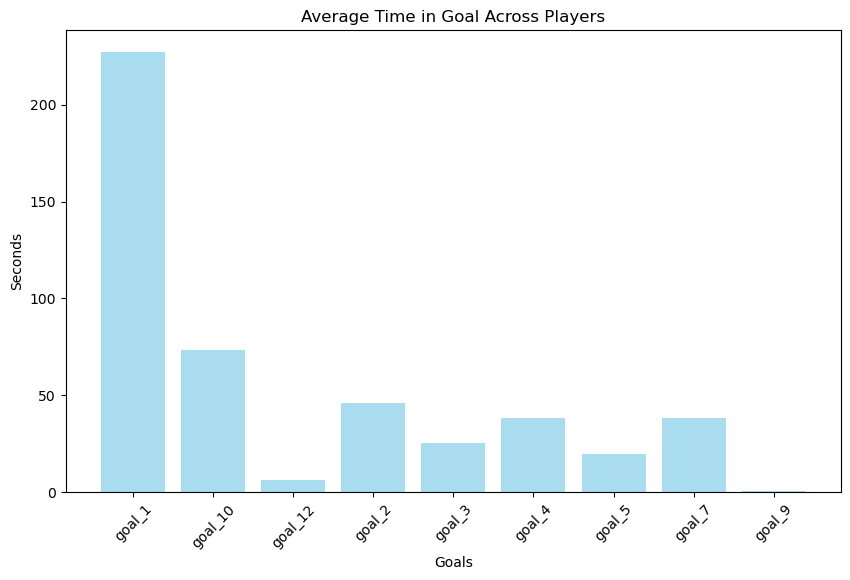

In [30]:
plt.figure(figsize=(10, 6))
plt.bar(goal_times_sum_by_goal['goals'], goal_times_sum_by_goal['mean'], capsize=5, color='skyblue', alpha=0.7) #yerr=impasse_counts_by_goal_summary['std']
plt.xlabel('Goals')
plt.ylabel('Seconds')
plt.title('Average Time in Goal Across Players') #with Standard Deviation
plt.xticks(rotation=45)
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/average_time_in_goal.png', dpi=300)
plt.show()

#### Distribution of Impasses 

In [31]:
grouped_impasses = df.groupby(['ID', 'impasses']).size().reset_index(name='count')
average_impasse = grouped_impasses.groupby('impasses')['count'].mean().reset_index(name='average_impasse_count')
average_impasse

,impasses,average_impasse_count
0,impasse_1,22.300000
1,impasse_2,2.875000
2,impasse_3,9.222222
3,impasse_4,8.000000
4,impasse_5,10.800000
5,impasse_6,6.888889


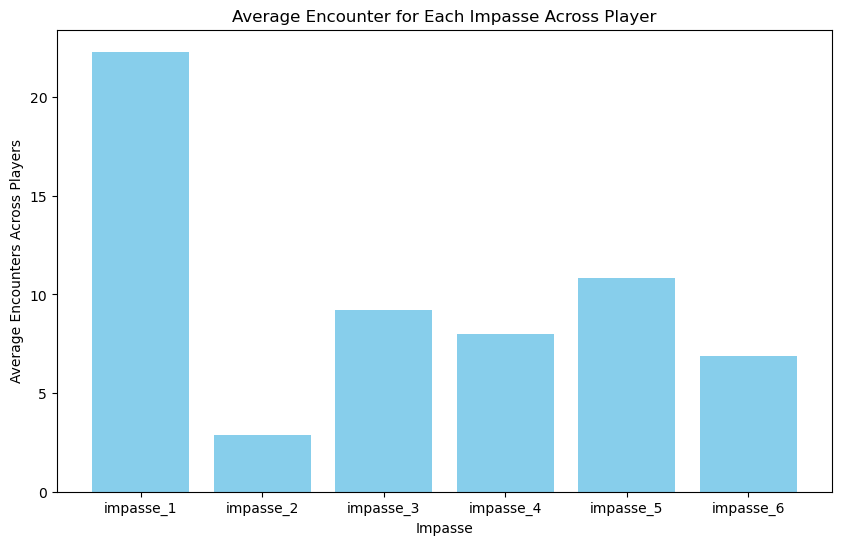

In [32]:
# Visualize the distribution of the 'Total' column

# Create a bar chart
plt.figure(figsize=(10, 6))
plt.bar(average_impasse['impasses'], average_impasse['average_impasse_count'], color='skyblue')

# Add title and labels
plt.title('Average Encounter for Each Impasse Across Player')
plt.xlabel('Impasse')
plt.ylabel('Average Encounters Across Players')

# Show plot
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/average_impasse_encounters.png', dpi=300)
plt.show()

#### Statistics for Impasses By Goal

In [33]:
df_goals['impasses'] = df['impasses'].fillna('')
impasse_counts_by_goal = df_goals[df_goals['impasses'].str.contains("impasse_")].groupby(['ID', 'goals']).size().reset_index(name='impasse_count')
impasse_counts_by_goal

/var/folders/t1/sdbl9_cd061431ynt1cns5hh0000gn/T/ipykernel_2193/1679591835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_goals['impasses'] = df['impasses'].fillna('')


,ID,goals,impasse_count
0,15,goal_1,14
1,15,goal_10,14
2,15,goal_2,7
3,15,goal_4,29
4,49,goal_1,8
5,49,goal_12,6
6,49,goal_2,5
7,101,goal_1,6
8,101,goal_9,1
9,157,goal_1,13


In [34]:
impasse_counts_by_goal_summary = impasse_counts_by_goal.groupby('goals')['impasse_count'].agg(['mean', 'std']).reset_index()
impasse_counts_by_goal_summary

,goals,mean,std
0,goal_1,12.900000,4.458450
1,goal_10,14.750000,11.586630
2,goal_12,5.000000,1.732051
3,goal_2,10.444444,9.166667
4,goal_3,2.285714,1.496026
5,goal_4,19.333333,15.885003
6,goal_5,3.500000,2.121320
7,goal_7,6.000000,0.000000
8,goal_9,1.000000,0.000000


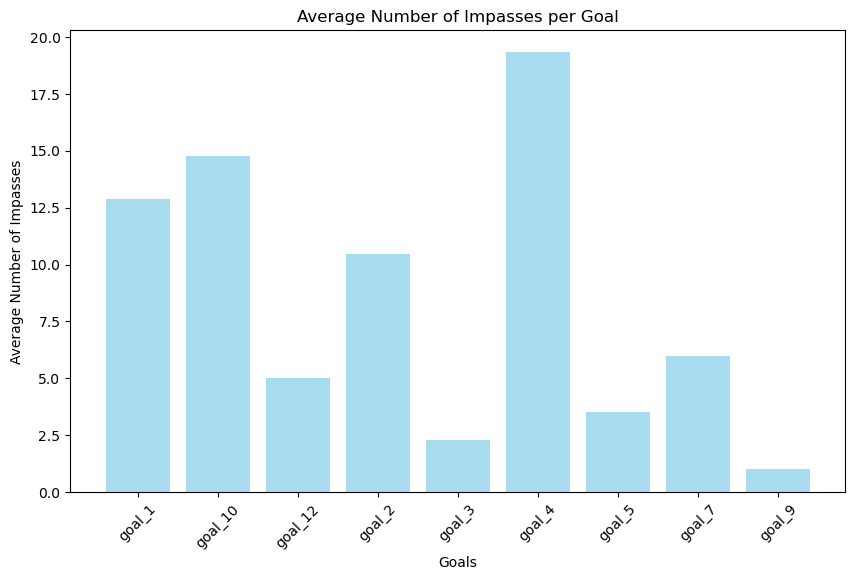

In [35]:
plt.figure(figsize=(10, 6))
plt.bar(impasse_counts_by_goal_summary['goals'], impasse_counts_by_goal_summary['mean'], capsize=5, color='skyblue', alpha=0.7) #yerr=impasse_counts_by_goal_summary['std']
plt.xlabel('Goals')
plt.ylabel('Average Number of Impasses')
plt.title('Average Number of Impasses per Goal') #with Standard Deviation
plt.xticks(rotation=45)
plt.savefig('/Users/baselhussein/Projects/impossible_goals/brick_wall/output/average_impasse_encounters_per_goal.png', dpi=300)
plt.show()

In [36]:
df['first_goal_change'] = df['goals'] != df.groupby('ID')['goals'].shift(1)
df['cumulative_sum_group'] = df.groupby('ID')['first_goal_change'].cumsum()

grouped_df = df.groupby(['ID', 'cumulative_sum_group']).agg({'time_offset': 'sum'}).reset_index()
first_goal_sum = grouped_df[grouped_df['cumulative_sum_group'] == 1].drop(columns='cumulative_sum_group')

first_goal_sum['seconds_to_first_goal_switch'] = first_goal_sum['time_offset'] / 1000
first_goal_sum.drop(columns=['time_offset'], inplace=True)

df_goal_change_time_index = first_goal_sum.reset_index(drop=True)
df_goal_change_time_index

,ID,seconds_to_first_goal_switch
0,15,13.434
1,49,1.850
2,69,0.000
3,101,21.767
4,157,8.000
5,159,18.333
6,160,24.966
7,178,20.133
8,187,82.550
9,234,14.650


#### Number of Inputs While Exploring 

In [37]:
inputs_during_explore = df_explore[df_explore['Event_type'] == 'input'].groupby('ID').size().reset_index(name='input_count_exploring')
inputs_during_explore

,ID,input_count_exploring
0,15,303
1,49,40
2,69,1
3,101,36
4,157,73
5,159,811
6,160,407
7,178,89
8,187,491
9,234,337


#### Total Time In Level 

In [38]:
df_time_in_level = df.groupby('ID')['time_offset'].sum().reset_index()
df_time_in_level['time_in_level_seconds'] = df_time_in_level['time_offset'] / 1000
df_time_in_level.drop(columns=['time_offset'], inplace=True)
df_time_in_level

,ID,time_in_level_seconds
0,15,715.950
1,49,101.267
2,69,0.000
3,101,76.950
4,157,64.833
5,159,508.533
6,160,1915.750
7,178,183.800
8,187,852.600
9,234,428.100


### Combine Features 

#### Prepare Columns 

##### Unique Goals

In [39]:
df_unique_goals_by_id_index = df_unique_goals_by_id.reset_index()
df_unique_goals_by_id_index

,ID,unique_goals
0,15,5
1,49,3
2,101,2
3,157,4
4,159,5
5,160,7
6,178,4
7,187,4
8,234,6
9,250,7


##### Returns to Previous Goals 

In [40]:
df_returns_numeric_reset = df_returns_numeric.reset_index()
df_returns_numeric_reset

goals,ID,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
0,15,9,7,0,2,0,0,0,0,0,18
1,49,2,0,1,0,0,0,0,0,0,3
2,101,0,0,0,0,0,0,0,0,0,0
3,157,6,0,0,0,0,0,0,1,0,7
4,159,23,0,0,3,2,0,0,1,0,29
5,160,10,5,0,3,4,0,1,1,0,24
6,178,3,0,0,0,0,0,0,0,0,3
7,187,10,0,0,1,5,2,0,0,0,18
8,234,7,3,1,3,1,0,0,0,0,15
9,250,3,4,0,1,1,0,0,1,0,10


In [41]:
df_returns_numeric_reset.index.name = None
df_returns_numeric_reset

goals,ID,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
0,15,9,7,0,2,0,0,0,0,0,18
1,49,2,0,1,0,0,0,0,0,0,3
2,101,0,0,0,0,0,0,0,0,0,0
3,157,6,0,0,0,0,0,0,1,0,7
4,159,23,0,0,3,2,0,0,1,0,29
5,160,10,5,0,3,4,0,1,1,0,24
6,178,3,0,0,0,0,0,0,0,0,3
7,187,10,0,0,1,5,2,0,0,0,18
8,234,7,3,1,3,1,0,0,0,0,15
9,250,3,4,0,1,1,0,0,1,0,10


In [42]:
df_returns_numeric_total = df_returns_numeric_reset[['ID', 'total']]
df_returns_numeric_total.columns.name = None
df_returns_numeric_total.rename(columns={'total': 'total_returns'}, inplace=True)
df_returns_numeric_total

/var/folders/t1/sdbl9_cd061431ynt1cns5hh0000gn/T/ipykernel_2193/4274987128.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_returns_numeric_total.rename(columns={'total': 'total_returns'}, inplace=True)


,ID,total_returns
0,15,18
1,49,3
2,101,0
3,157,7
4,159,29
5,160,24
6,178,3
7,187,18
8,234,15
9,250,10


##### Impasses Per Player 

In [43]:
df_impasses_counts_by_player

,impasses
ID,
15,72
49,19
69,0
101,8
157,23
159,121
160,63
178,24
187,131


##### Time Per Goal 

In [44]:
goal_times_sum

,ID,goals,time_offset,seconds,minutes
0,15,goal_1,361150,361.150,6.019167
1,15,goal_10,59699,59.699,0.994983
2,15,goal_2,19634,19.634,0.327233
3,15,goal_3,0,0.000,0.000000
4,15,goal_4,37484,37.484,0.624733
5,49,goal_1,57367,57.367,0.956117
6,49,goal_12,3217,3.217,0.053617
7,49,goal_2,7200,7.200,0.120000
8,101,goal_1,21767,21.767,0.362783
9,101,goal_9,600,0.600,0.010000


In [45]:
average_time_per_goal = goal_times_sum.groupby('ID')['seconds'].mean()
df_average_time_per_goal = pd.DataFrame(average_time_per_goal)
df_average_time_per_goal.rename(columns={'seconds': 'seconds_per_goal'}, inplace=True)
df_average_time_per_goal

,seconds_per_goal
ID,
15,95.593400
49,22.594667
101,11.183500
157,7.999500
159,59.333800
160,185.694857
178,33.883000
187,153.266750
234,47.941833


##### Time to First Goal Switch 

In [46]:
df_goal_change_time_index

,ID,seconds_to_first_goal_switch
0,15,13.434
1,49,1.850
2,69,0.000
3,101,21.767
4,157,8.000
5,159,18.333
6,160,24.966
7,178,20.133
8,187,82.550
9,234,14.650


##### Total Time in Level

In [47]:
df_time_in_level

,ID,time_in_level_seconds
0,15,715.950
1,49,101.267
2,69,0.000
3,101,76.950
4,157,64.833
5,159,508.533
6,160,1915.750
7,178,183.800
8,187,852.600
9,234,428.100


##### Inputs While Exploring

In [48]:
inputs_during_explore

,ID,input_count_exploring
0,15,303
1,49,40
2,69,1
3,101,36
4,157,73
5,159,811
6,160,407
7,178,89
8,187,491
9,234,337


##### Impasses Per Goal

In [49]:
goal_impasse_counts_pre_solution

,ID,goals,impasses
0,15,goal_1,14
1,15,goal_10,14
2,15,goal_2,7
3,15,goal_3,0
4,15,goal_4,29
5,49,goal_1,8
6,49,goal_12,6
7,49,goal_2,5
8,101,goal_1,6
9,101,goal_9,1


In [50]:
impasse_per_goal = goal_impasse_counts_pre_solution.groupby('ID')['impasses'].mean().reset_index()
avg_impasse_per_goal = impasse_per_goal.rename(columns={'impasses': 'avg_impasse_per_goal'})
avg_impasse_per_goal

,ID,avg_impasse_per_goal
0,15,12.800000
1,49,6.333333
2,101,3.500000
3,157,5.250000
4,159,12.400000
5,160,8.000000
6,178,5.500000
7,187,15.500000
8,234,5.000000
9,250,9.000000


#### Merge Function 

In [51]:
# Sample DataFrames
dfs_merge = [df_unique_goals_by_id_index, df_returns_numeric_total, df_average_time_per_goal,
             df_goal_change_time_index, df_impasses_counts_by_player, inputs_during_explore, df_time_in_level, 
             avg_impasse_per_goal]

# Merge the DataFrames on the ID column using functools.reduce
df_cluster_features = reduce(lambda left, right: pd.merge(left, right, on='ID'), dfs_merge)

In [52]:
df_cluster_features

,ID,unique_goals,total_returns,seconds_per_goal,seconds_to_first_goal_switch,impasses,input_count_exploring,time_in_level_seconds,avg_impasse_per_goal
0,15,5,18,95.593400,13.434,72,303,715.950,12.800000
1,49,3,3,22.594667,1.850,19,40,101.267,6.333333
2,101,2,0,11.183500,21.767,8,36,76.950,3.500000
3,157,4,7,7.999500,8.000,23,73,64.833,5.250000
4,159,5,29,59.333800,18.333,121,811,508.533,12.400000
5,160,7,24,185.694857,24.966,63,407,1915.750,8.000000
6,178,4,3,33.883000,20.133,24,89,183.800,5.500000
7,187,4,18,153.266750,82.550,131,491,852.600,15.500000
8,234,6,15,47.941833,14.650,32,337,428.100,5.000000
9,250,7,10,39.676286,31.017,70,353,603.234,9.000000


### Export

In [53]:
df_cluster_features.to_csv('/Users/baselhussein/Projects/impossible_goals/brick_wall/data/cluster_features_quit.csv', index=False)